
 Original data: 
  Wallet_ID  Balance_USD  Trades
0      0x1A        15000      50
1      0x2B          200       2
2      0x3C        18000      65
3      0x4D          150       1
4      0x2B          200       2
5      0x5E        12000      45

 After dropping duplicates: 
  Wallet_ID  Balance_USD  Trades
0      0x1A        15000      50
1      0x2B          200       2
2      0x3C        18000      65
3      0x4D          150       1
5      0x5E        12000      45

 Data after scaling: 
[[0.83193277 0.765625  ]
 [0.00280112 0.015625  ]
 [1.         1.        ]
 [0.         0.        ]
 [0.66386555 0.6875    ]]

 Trained the K-Means model!


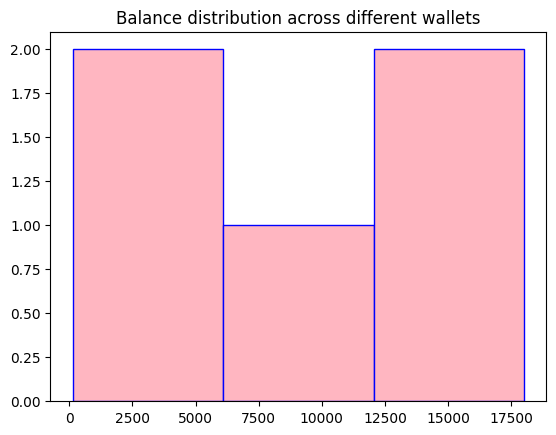

In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data = {
    'Wallet_ID': ['0x1A', '0x2B', '0x3C', '0x4D', '0x2B', '0x5E'],
    'Balance_USD': [15000, 200, 18000, 150, 200, 12000],
    'Trades': [50, 2, 65, 1, 2, 45]
}

df = pd.DataFrame(data)
print("\n Original data: ")
print(df)

# Drop the duplicate row (Wallet 0x2B sneaked in twice!).
df = df.drop_duplicates()
print("\n After dropping duplicates: ")
print(df)

# Create your X by selecting ONLY the Balance_USD and Trades columns
X = df[['Balance_USD', 'Trades']]

# Use MinMaxScaler() to squish those massive 15,000 balances down to a 0-1 
# scale alongside the tiny trade numbers, and update your X with the scaled numbers.
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
print("\n Data after scaling: ")
print(X)

# Train a KMeans model with n_clusters=2 on your scaled X.
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
print("\n Trained the K-Means model!")

# Instead of a scatter plot, draw a Histogram of the Balance_USD column 
# to see how the money is distributed across the wallets! 
plt.hist(df['Balance_USD'], bins=3, color='lightpink', edgecolor='blue')
plt.title("Balance distribution across different wallets")
plt.show()
